### 加载数据

In [2]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio import RiskMeasure, PerfMeasure, RatioMeasure
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
set_config(transform_output="pandas")
init_logger("Simulation_252")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\Simulation_252.log


In [3]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2141 只 | 2604 天 | 2016-01-04 ~ 2026-09-18
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2603 天 x 2137 资产 | 列集一致: True


### 参数搜索
- Walkforward:
    - CombinatorialPurgedCV

In [5]:
from wf_cpcv_search import load_nested_config
from cpcv_search_base import build_pipeline_src
from walkforward_parameter_search import compute_grid_size
from wf_cpcv_search import nested_adaptive_search, adaptive_multi_paths, build_test_parts, summarize_fold_params,summarize_top_k_params
from cpcv_analysis import discrete_lhs_safe, diagnose_oos_lhs, report_ann_distribution, turnover_series
from cpcv_analysis import plot_oos_vs_bench,excess_vs_bench, plot_paths_curve
from wf_cpcv_robustness import (perturbation_mc, sensitivity_curves, sensitivity_heatmap, topk_paths_eval,)
from wf_cpcv_ablation import ablate

In [6]:
log_print("mean(Annualized Sharpe Ratio)/2 - mean(MAXDD) + mean(SKEW)", section='Ojective', echo=False)
log_print(build_pipeline_src(), section="Model Pipeline", echo=False)

In [7]:
search_space = {'nondomin__min_n_assets': {'low': 5, 'high': 55, 'step': 5},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.5, 'step': 0.1},
 'extremes__k': {'low': 0.1, 'high': 0.6, 'step': 0.1},
 'nondomin__fitness_measures': [
    "mean-variance-kurt",
    "mean-variance-maxdd-kurt",
    "mean-variance-avgdd-kurt",
    "mean-semideviation-avgdd",
    "mean-mad-maxdd-kurt",
    "mean-mad-avgdd-kurt",
    "mean-mad-maxdd-cvar-kurt",
    "mean-mad-maxdd-cvar-sharpe",
    "mean-mad-avgdd-cvar-kurt",
    "mean-mad-avgdd-cvar-sharpe",
    ],
 'train_size': {'low': 252, 'high': 756, 'step': 126}}  # inner train size
log_print(search_space, section='Parameter Space', echo=False)
compute_grid_size(search_space)

49500

In [8]:
search_params = {'test_size': 252,
  'train_size': 756+252,
  'n_test_folds': 2,
  'n_jobs': 4,
  'cv_n_jobs': 8,
  'n_trials': 2000,
  'patience': 100,
  'sampler': 'tpe',
  'min_delta': 0.0001,
  'outer_purged_size': 0,
  'outer_reduce_test': False,
  'seed': 420,
  'verbose': True}
log_print(search_params, section="Search Parameter", echo=False)

In [53]:
fold_results = nested_adaptive_search(X,space=search_space, **search_params)

  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 0: mean score=0.8031 | test_ann=0.1140 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 1: mean score=0.6874 | test_ann=0.0250 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

...

Fold 3: mean score=0.6221 | test_ann=0.0979 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 4: mean score=0.7155 | test_ann=0.1657 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 5: mean score=0.3720 | test_ann=0.1826 | test_days=252


#### Train vs Test

In [54]:
train_population = Population([result['train'] for result in fold_results])
test_population = Population([result['test'] for result in fold_results])
train_population.set_portfolio_params(tag="Train")
test_population.set_portfolio_params(tag="Test")
population = train_population + test_population

In [55]:
population.plot_measures(
    x=RiskMeasure.ANNUALIZED_STANDARD_DEVIATION,
    y=PerfMeasure.ANNUALIZED_MEAN,
    color_scale=RatioMeasure.ANNUALIZED_SHARPE_RATIO,
    hover_measures=[RiskMeasure.MAX_DRAWDOWN, RatioMeasure.ANNUALIZED_SORTINO_RATIO],
)

### Step 1 | IS 审计：每折 P Luck + Top-K 候选
- dsr = 该折最优分数超过"纯运气挑最优"基准的经验概率（H0 噪声 MC deflate，N = 参数去重后的真实试验数）。 margin = sr_obs − E[max_N]，max_p95 为运气基准 95% 分位。
- gap2top1（summarize_top_k_params 的列）= IS 侧 top1 与 top2 的分数落差： 落差小 → 参数处在平台（好信号）；落差大 → top1 可能是运气孤峰（坏信号）。

In [56]:
log_print(summarize_fold_params(fold_results).to_string(),section='Best Parameter', echo=True)

   fold   score  p_luck  margin  train ASR  test ASR  nondomin__min_n_assets  nondomin__threshold  correlate__threshold  extremes__k  train_size                     fitness  n_trials
0     0  0.8031  0.9693 -0.0736     0.9739    0.6975                      55                 -0.3                   0.1          0.4         378    mean-variance-maxdd-kurt        80
1     1  0.6874  0.0847  0.0496     1.1755    1.1069                      45                 -0.4                   0.2          0.5         252    mean-variance-avgdd-kurt        91
2     2  0.3973  0.6178 -0.0134     1.3281    0.5852                      55                 -0.5                   0.2          0.5         504  mean-mad-avgdd-cvar-sharpe        91
3     3  0.6221  0.9385 -0.0922     0.5778    2.8774                      35                 -0.5                   0.1          0.6         504  mean-mad-maxdd-cvar-sharpe        93
4     4  0.7155  0.9132 -0.1269     0.8426    0.9556                      15         

In [57]:
topk = summarize_top_k_params(fold_results, k=5)         # 行 = (fold, rank)
print(topk[topk["rank"] <= 3][['fold','rank','score','gap2top1']])                    # 每折 top1/top2 候选 + gap2top1

    fold  rank   score  gap2top1
0      0     1  0.8031    0.0000
1      0     2  0.8027    0.0003
2      0     3  0.8012    0.0018
5      1     1  0.6874    0.0000
6      1     2  0.6363    0.0510
7      1     3  0.6363    0.0510
10     2     1  0.3973    0.0000
11     2     2  0.3911    0.0062
12     2     3  0.3747    0.0225
15     3     1  0.6221    0.0000
16     3     2  0.6221    0.0000
17     3     3  0.6221    0.0000
20     4     1  0.7155    0.0000
21     4     2  0.6916    0.0239
22     4     3  0.6916    0.0239
25     5     1  0.3720    0.0000
26     5     2  0.2325    0.1394
27     5     3  0.1848    0.1871


### Step 2｜过拟合判据：DSR 低 + OOS 衰减
- 判据：WFE > 0.5 为稳健泛化（多数折满足）。
- "DSR 低 + OOS 显著下降" = 内层选择偏差校正后无真实优势 + 样本外掉队 → 该折结论不可信，

In [58]:
df = summarize_fold_params(fold_results).copy()
df["WFE"] = df["test ASR"] / df["train ASR"]      # 每折 IS→OOS 衰减比
df["flag"] = (df["p_luck"] > 0.5) & (df["WFE"] < 0.5)   # 运气嫌疑高 + 衰减 = 过拟合嫌疑折
print(df[["fold", "p_luck", "train ASR", "test ASR", "WFE", "flag"]])

   fold  p_luck  train ASR  test ASR       WFE   flag
0     0  0.9693     0.9739    0.6975  0.716193  False
1     1  0.0847     1.1755    1.1069  0.941642  False
2     2  0.6178     1.3281    0.5852  0.440629   True
3     3  0.9385     0.5778    2.8774  4.979924  False
4     4  0.9132     0.8426    0.9556  1.134109  False
5     5  0.0292     1.1562    2.1643  1.871908  False


### Step 3｜Top-K 候选 OOS 多路径压测
- 窗口自动从 folds 推导（折位 1:1）；如需 notebook 原压测口径（如 `n_test_folds=4`），
  以显式键传入：`topk_paths_eval(X, folds, paths_kwargs={"n_test_folds": 4})`。
- 价值在**参数高原的 OOS 侧印证**：gap2top1 小的候选若 OOS 同样接近，说明生产参数处在稳定平台。

In [59]:
eval_ = topk_paths_eval(X, fold_results, k=10)            # 每折 top1~5 全部进 CPCV 多路径压测

rank1: 完整OOS路径 | 6 折拼接 | 1512 天
rank2: 完整OOS路径 | 6 折拼接 | 1512 天
rank3: 完整OOS路径 | 6 折拼接 | 1512 天
rank4: 完整OOS路径 | 6 折拼接 | 1512 天
rank5: 完整OOS路径 | 6 折拼接 | 1512 天
rank6: 完整OOS路径 | 6 折拼接 | 1512 天
rank7: 完整OOS路径 | 6 折拼接 | 1512 天
rank8: 完整OOS路径 | 6 折拼接 | 1512 天
rank9: 完整OOS路径 | 6 折拼接 | 1512 天
rank10: 完整OOS路径 | 6 折拼接 | 1512 天


In [60]:

paths = eval_["paths"]                            # MultiIndex (fold, rank, path)
audit = eval_["audit"]                            # IS 侧审计，与 paths 按 (fold, rank) 对齐
sharpe = paths["annualized_sharpe_ratio"].groupby("rank").mean()
print(sharpe)              # rank 均值对比（不选参，只看高原）

rank
1     0.996914
2     0.825377
3     0.999016
4     0.756429
5     0.856162
6     1.007575
7     0.785454
8     1.034526
9     0.969479
10    0.767577
Name: annualized_sharpe_ratio, dtype: float64


In [61]:
log_print(paths, section="Top 10 参数组合OOS:ASR,MEAN,MAXDD")

      annualized_sharpe_ratio  annualized_mean  max_drawdown
rank                                                        
1                    0.996914         0.113254      0.140552
2                    0.825377         0.102207      0.128347
3                    0.999016         0.113462      0.113610
4                    0.756429         0.083522      0.143042
5                    0.856162         0.102195      0.128347
6                    1.007575         0.119545      0.113610
7                    0.785454         0.120239      0.174183
8                    1.034526         0.131132      0.127663
9                    0.969479         0.102990      0.163199
10                   0.767577         0.113625      0.164897


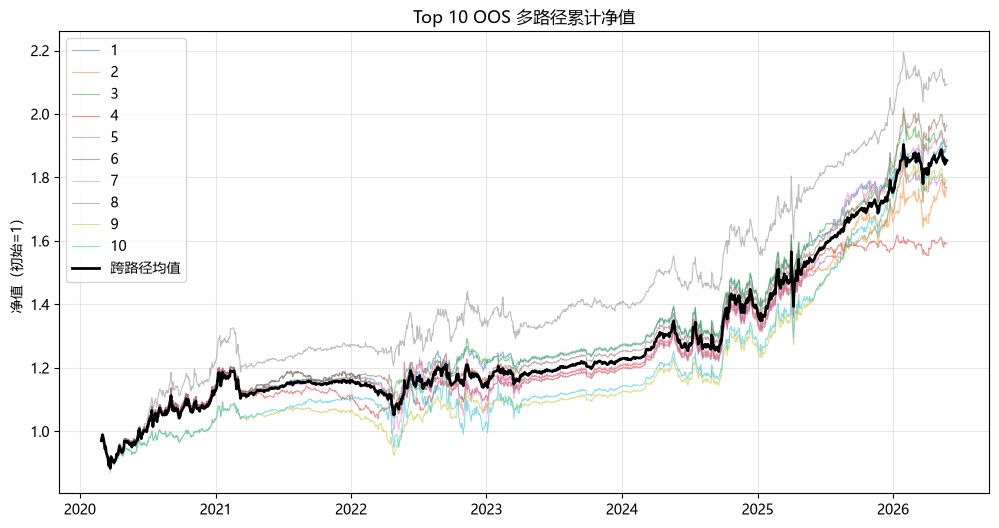

In [62]:
top_k_mpts = Population([mpt for mpt in eval_['mpts'].values()])
plot_paths_curve(top_k_mpts, title='Top 10 OOS 多路径累计净值', labels=[k for k in eval_['mpts'].keys()])

### Ensemble

In [63]:
from wf_topk_ensemble import topk_ensemble_eval

In [64]:
ens = topk_ensemble_eval(X, fold_results, k=10) 

Fold 0: 候选=10 | top1资产=4 | 融合池=7（重叠=4）| top1_test=0.6975 | ens_test=1.0167
Fold 1: 候选=10 | top1资产=5 | 融合池=18（重叠=5）| top1_test=1.1069 | ens_test=0.0285
Fold 2: 候选=10 | top1资产=7 | 融合池=11（重叠=7）| top1_test=0.5852 | ens_test=0.4918
Fold 3: 候选=10 | top1资产=3 | 融合池=6（重叠=3）| top1_test=2.8774 | ens_test=2.5574
Fold 4: 候选=10 | top1资产=3 | 融合池=3（重叠=3）| top1_test=0.9556 | ens_test=1.0410
Fold 5: 候选=10 | top1资产=10 | 融合池=38（重叠=10）| top1_test=2.1643 | ens_test=2.5721
完整 OOS 路径: 6 折拼接, 共 1512 天


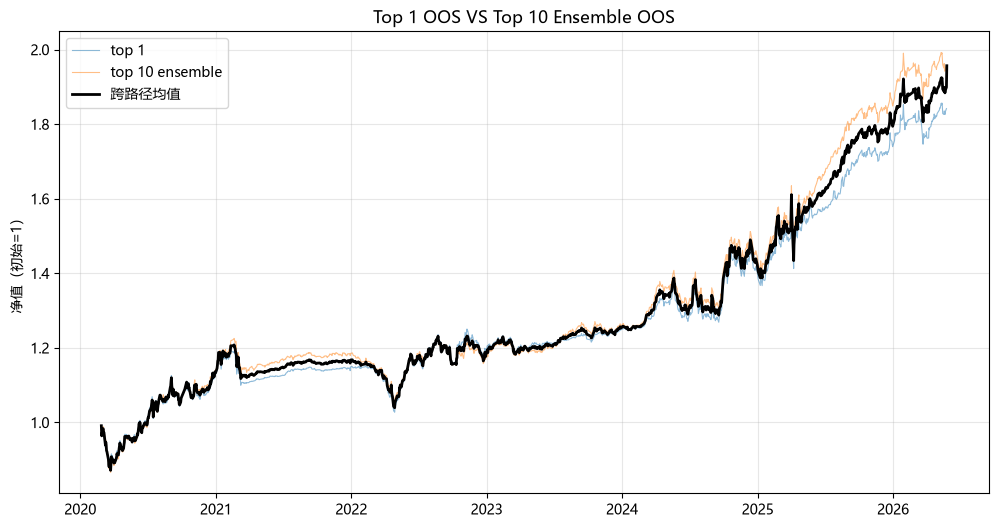

In [65]:
ensemble_mpt = Population([ens['paths']['top1'], ens['paths']['ensemble']])
plot_paths_curve(ensemble_mpt, title='Top 1 OOS VS Top 10 Ensemble OOS', labels=['top 1','top 10 ensemble'])

In [19]:
log_print(ens['paths']['ensemble'].summary(),section='Top 5 Ensemble OSS Summary',echo=False)

### Step 4｜单参数敏感性曲线
- 每折只动目标参数、其余保持生产值（fitness 固定 top1）；`frac=0` 档即生产值本身（锚点）。
- 默认覆盖**全部数值参数含 `train_size`**（它是搜索维度之一，扰动后评估即用扰动后的拟合窗口长度）。
- 读图：参数高原 = ±30% 内绩效平缓；孤峰 = 仅生产值附近突出（与 IS 侧 gap2top1 互证）。
- 只评估单折 OOS → 无 CPCV 展开，成本低，可全参数全档位跑。

In [16]:
curves = sensitivity_curves(X, fold_results, reduce_test=False)             # 默认 ±10/20/30% 六档 × 全部数值参数
c = curves[curves["param"] == "extremes__k"]
ax = c.pivot_table(index="frac", columns="fold",
                   values="annualized_sharpe_ratio").plot(marker="o")

Fold 0: 单参网格完成 (5 参数 × 6 档)
Fold 1: 单参网格完成 (5 参数 × 6 档)
Fold 2: 单参网格完成 (5 参数 × 6 档)
Fold 3: 单参网格完成 (5 参数 × 6 档)
Fold 4: 单参网格完成 (5 参数 × 6 档)
Fold 5: 单参网格完成 (5 参数 × 6 档)
Fold 6: 单参网格完成 (5 参数 × 6 档)
Fold 7: 单参网格完成 (5 参数 × 6 档)
Fold 8: 单参网格完成 (5 参数 × 6 档)
Fold 9: 单参网格完成 (5 参数 × 6 档)
Fold 10: 单参网格完成 (5 参数 × 6 档)
Fold 11: 单参网格完成 (5 参数 × 6 档)
Fold 12: 单参网格完成 (5 参数 × 6 档)


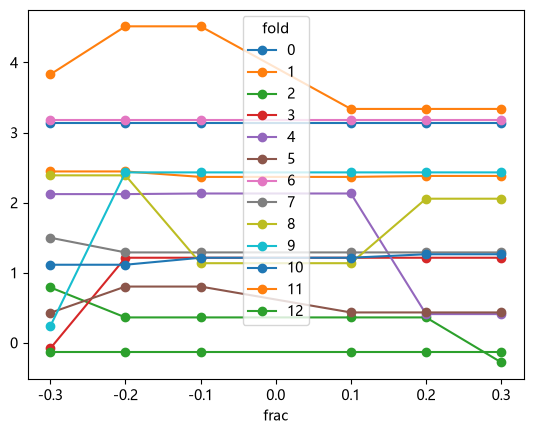

In [17]:
plt.show()

### Step 5｜双参数联合热力图（checklist 4.2）

- 返回 `{fold: DataFrame(index=frac_a, columns=frac_b), "mean": 跨折逐格平均}`。
- 读图：各档平缓 → 联合高原（稳健）；仅 (0,0) 突出 → 联合孤峰（脆弱）；
  对角陡峭 → 两参数互补/冲突（交互项存在）。

Fold 0: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 1: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 2: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 3: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 4: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 5: extremes__k×correlate__threshold 热力图 (5×5) 完成


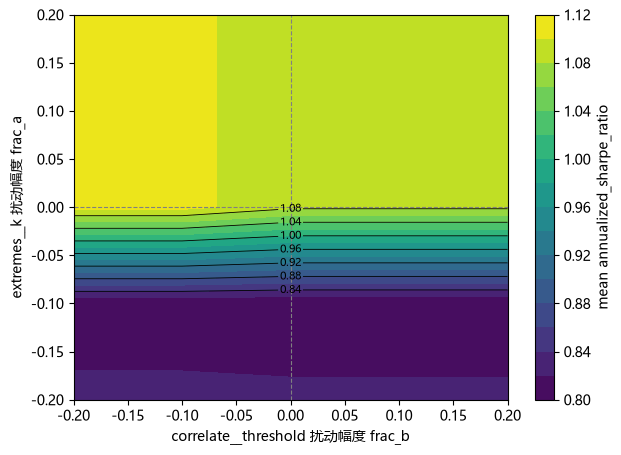

In [66]:
import numpy as np
import matplotlib.pyplot as plt

grids = sensitivity_heatmap(X, fold_results, param_a="extremes__k",
                            param_b="correlate__threshold",
                            reduce_test=False)
mean = grids["mean"]                          # 行=frac_a, 列=frac_b, 值=跨折平均ASR
Xg, Yg = np.meshgrid(mean.columns, mean.index)   # x=frac_b, y=frac_a，与 values[i,j] 对齐
fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(Xg, Yg, mean.values, levels=15, cmap="viridis")   # 彩色填充
cs = ax.contour(Xg, Yg, mean.values, levels=8, colors="k", linewidths=0.6)  # 等值线
ax.clabel(cs, inline=True, fontsize=8)        # 标数值
ax.axhline(0, color="gray", lw=0.8, ls="--")  # 生产值锚点十字线（0,0 = 未扰动）
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("correlate__threshold 扰动幅度 frac_b")
ax.set_ylabel("extremes__k 扰动幅度 frac_a")
fig.colorbar(cf, label="mean annualized_sharpe_ratio")
plt.show()

### Step 6｜消融实验

- 臂：`full`（基准）/ `no_extremes` / `no_nondomin` / `no_correlate` / `no_extremes_correlate`。
- 每臂 = 固定每折最优参数 × 剔除对应管线步骤 × CPCV 多路径压测（同窗同口径对比）。
- 判读：全臂样本路径数一致（每折 = `n_test_folds` 组合路径），绩效差距即模块边际贡献；
  某模块剔除后绩效**不降反升** → 该模块负贡献，考虑剔除后重搜（会作废旧 OOS）。

In [67]:
frames, summary = ablate(X, fold_results)                # arms=None = 全部 5 臂
summary

,说明,折数,天数,annualized_mean,annualized_sharpe_ratio,max_drawdown,skew,kurtosis
臂,,,,,,,,
full,全管线（基准）,6,1512,0.113254,0.996914,0.140552,-0.234676,11.730424
no_extremes,无峰度预筛（剔除 extremes 步骤）,6,1512,0.072999,1.107309,0.076673,-0.047663,8.511160
no_nondomin,无非支配筛选（剔除 nondomin 步骤）,6,1512,0.119434,1.190413,0.159496,-0.177436,6.161467
no_correlate,无去相关（剔除 correlate 步骤）,6,1512,0.110335,0.786143,0.271834,-0.505850,9.015565
no_extremes_correlate,剔除 extremes + correlate,6,1512,0.111029,1.035572,0.187002,-0.583430,8.715972


In [24]:
log_result(summary.to_string(), section="消融实验")

### Step 7｜参数扰动蒙特卡洛 + 判定

In [ ]:
out = perturbation_mc(X, fold_results, fitness_topk=5)                   # R=None → ceil(500 / 折数)，总样本 ≥ 500

In [150]:
out['verdict']

,指标,样本数,prob>0,median,p95,通过
0,annualized_mean,507,0.903353,0.113004,0.316511,True
1,annualized_sharpe_ratio,507,0.903353,1.261678,3.139579,True


In [151]:
out['fold_summary']

,n,annualized_mean_mean,annualized_mean_median,annualized_mean_p5,annualized_mean_p95,annualized_sharpe_ratio_mean,annualized_sharpe_ratio_median,annualized_sharpe_ratio_p5,annualized_sharpe_ratio_p95,max_drawdown_mean,...,max_drawdown_p95,skew_mean,skew_median,skew_p5,skew_p95,kurtosis_mean,kurtosis_median,kurtosis_p5,kurtosis_p95,pos_prob
fold,,,,,,,,,,,,,,,,,,,,,
0,39,0.114112,0.052112,0.017740,0.396740,1.292467,1.046858,0.295861,3.139579,0.036794,...,0.054353,0.035468,0.242569,-0.726920,0.553630,6.161362,6.350444,5.386924,6.641066,1.000000
1,39,0.195789,0.211091,0.090474,0.288069,1.883484,1.904748,1.071884,2.735408,0.065966,...,0.084900,-0.212261,-0.253512,-0.449060,0.269177,4.041860,3.945983,3.697458,4.810543,0.974359
2,39,0.046928,0.042260,0.002194,0.167671,0.880226,0.738002,0.043091,2.021897,0.032544,...,0.070278,-0.176149,-0.204486,-0.502634,0.371917,4.022140,3.236600,2.566316,6.451092,0.948718
3,39,0.105298,0.113004,-0.021499,0.206258,2.029180,2.520180,-0.315142,3.648628,0.027009,...,0.062454,0.002319,0.097402,-0.371923,0.344133,5.147773,5.029438,3.082278,6.901054,0.923077
4,39,0.150439,0.274079,-0.265825,0.274087,1.184110,2.121271,-1.994514,2.130047,0.071298,...,0.188325,-0.114541,-0.094199,-0.508079,0.224505,4.287416,3.650374,3.082842,5.414486,0.820513
5,39,0.034034,0.035678,-0.043088,0.084941,0.278861,0.333539,-0.397490,0.676169,0.071297,...,0.086521,-0.426293,-0.505634,-0.744690,0.010939,4.645636,4.594550,3.328906,6.006268,0.846154
6,39,0.128697,0.127023,0.112960,0.159354,1.983736,1.667762,0.961118,3.177725,0.058187,...,0.106783,0.376001,0.392628,0.024525,0.494194,4.841346,5.233428,3.567264,5.620750,1.000000
7,39,0.068929,0.057047,-0.025251,0.131066,1.147436,1.190865,-0.480029,2.247332,0.033492,...,0.043910,-0.035558,0.031480,-0.280501,0.210641,3.895007,3.235186,2.608128,5.161216,0.871795
8,39,0.129383,0.136881,-0.003978,0.305578,1.874885,1.661872,-0.029823,3.241179,0.057772,...,0.126369,0.302549,0.516515,-0.173364,0.714591,5.078777,5.892025,2.591490,7.214605,0.820513


In [22]:
oos_pop = Population([fold['test'] for fold in fold_results])
oos_pop.plot_cumulative_returns()

In [23]:
oos_mpt = MultiPeriodPortfolio([fold['test'] for fold in fold_results],compounded=True)
oos_mpt.plot_cumulative_returns()

#### 路径采样

In [24]:
fold_paths = adaptive_multi_paths(X, fold_results, 
                                 test_size=search_params['test_size'], 
                                 train_size=search_params['train_size'],
                                 n_test_folds=search_params['n_test_folds'], n_jobs=8)

Fold 0: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 1: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 2: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 3: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 4: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 5: paths=13 | window=882 | inner_folds=14 | test_days=126
Fold 6: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 7: paths=11 | window=756 | inner_folds=12 | test_days=126
Fold 8: paths=13 | window=882 | inner_folds=14 | test_days=126
Fold 9: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 10: paths=13 | window=882 | inner_folds=14 | test_days=126
Fold 11: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 12: paths=11 | window=756 | inner_folds=12 | test_days=126


In [25]:
oos_blocks = build_test_parts(fold_paths, n_test_folds=search_params['n_test_folds'])
oos_paths = discrete_lhs_safe(oos_blocks, n_samples=1000, seed=42)
oos_mpts = Population([MultiPeriodPortfolio(path ,compounded=False) for path in oos_paths])

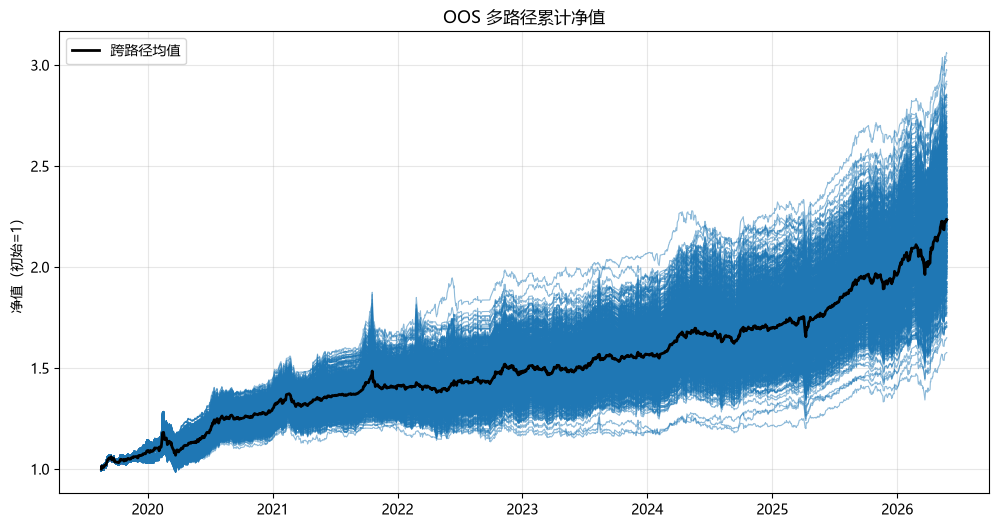

In [26]:
plot_paths_curve(oos_mpts)

In [27]:
log_print(oos_mpt.summary(),section='OSS Summary',echo=False)

### OOS诊断：
- Annualized Mean 分布
- PSR诊断
- 基准联动
- 换手频率

LHS多路径分布(1000条): 均值 0.1269 | 中位 0.1268 | 5% 0.1011 | 95% 0.1536
WF真实路径: 0.1125 | 分布中 -0.91σ | 分位 17.7%


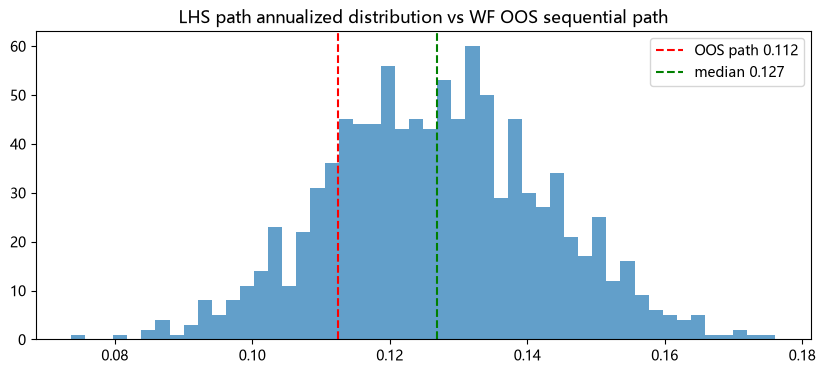

In [28]:
# 年化分布
path_anns = np.array([oos_mpt.annualized_mean for oos_mpt in oos_mpts])

oos_ann = oos_mpt.annualized_mean

report_ann_distribution(path_anns, oos_ann)

In [29]:
diagnose_result = diagnose_oos_lhs(lhs_paths=oos_paths)
del diagnose_result['mc_sharpes']
del diagnose_result['mc_mdds']
del diagnose_result['mc_psrs']
log_print(diagnose_result, section='OOS PSR Diagnose',echo=False)

[Info] 1000 LHS paths | OOS 1638 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 0.00%
  ✅ Sharpe 90% CI         : [0.933, 1.494]
  ✅ MDD median / worst-5%  : 12.01% / 20.23%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 1.2133
  ⚠️ PSR(0) median / 5%    : 100.00% / 100.00%


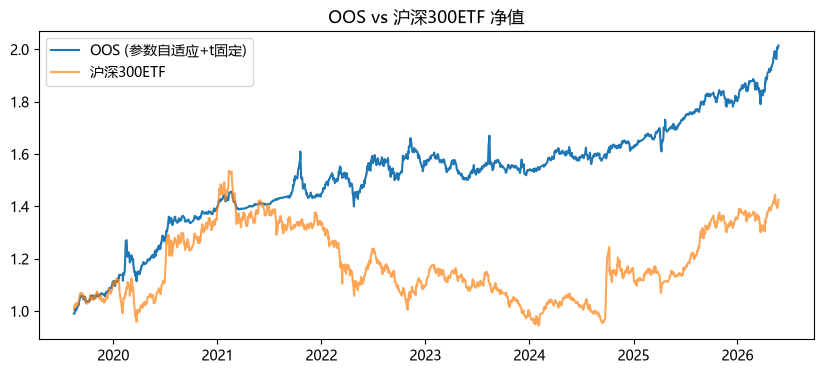

In [30]:
plot_oos_vs_bench(oos_mpt, bench_ret)

In [31]:

df_ex = excess_vs_bench(oos_mpts, bench_ret)
log_result(df_ex.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%", "mean"]].round(4),
           section="OOS vs 沪深300 相对收益分布")

      ann_excess  arith_excess      IR  winrate
5%        0.0423        0.0325  0.2120   0.5134
50%       0.0667        0.0582  0.3813   0.5256
95%       0.0920        0.0850  0.5540   0.5367
mean      0.0667        0.0583  0.3815   0.5254


### Simulation

In [9]:
from sl_simulation import load_sl_config, simulate_sl, summarize_sl

In [10]:
cfg  = load_sl_config()
cfg['space'] = search_space
cfg['search_kwargs'] = search_params

In [ ]:

cfg['stop_loss'] = {'min_epoch_days': 0,
    'conditions': [{
        'name': 'epoch_dd',
        'metric': 'drawdown',
        'op': '<=',
        'threshold': -0.10}]}

In [34]:
base = simulate_sl(X, folds=fold_results, cfg=cfg)

Epoch 0: 2019-08-16 -> 2020-02-26 (126d, expired) | src=fold_reuse | ASR=3.152 | 累计=21.52%
Epoch 1: 2020-02-27 -> 2020-03-23 (18d, sl:epoch_cumloss) | src=fold_reuse | ASR=-6.746 | 累计=-8.28%
决策日 2020-03-23: fresh CPCV 重搜 | 外层窗口 882 天 | test_size=126 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 2: 2020-03-24 -> 2020-09-23 (126d, expired) | src=fresh | ASR=2.645 | 累计=13.24%
决策日 2020-09-23: fresh CPCV 重搜 | 外层窗口 882 天 | test_size=126 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 3: 2020-09-24 -> 2021-04-06 (126d, expired) | src=fresh | ASR=0.355 | 累计=1.20%
决策日 2021-04-06: fresh CPCV 重搜 | 外层窗口 882 天 | test_size=126 | n_trials=2000


...

Epoch 12: 2025-04-08 -> 2025-10-14 (126d, expired) | src=fresh | ASR=3.468 | 累计=9.75%
决策日 2025-10-14: fresh CPCV 重搜 | 外层窗口 882 天 | test_size=126 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 13: 2025-10-15 -> 2026-04-21 (126d, expired) | src=fresh | ASR=0.707 | 累计=2.73%
决策日 2026-04-21: fresh CPCV 重搜 | 外层窗口 882 天 | test_size=126 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 14: 2026-04-22 -> 2026-08-14 (79d, end_of_data) | src=fresh | ASR=-0.464 | 累计=-1.47%


In [ ]:
res  = simulate_sl(X, cfg=cfg)

决策日 2026-03-19: fresh CPCV 重搜 | 外层窗口 882 天 | test_size=126 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

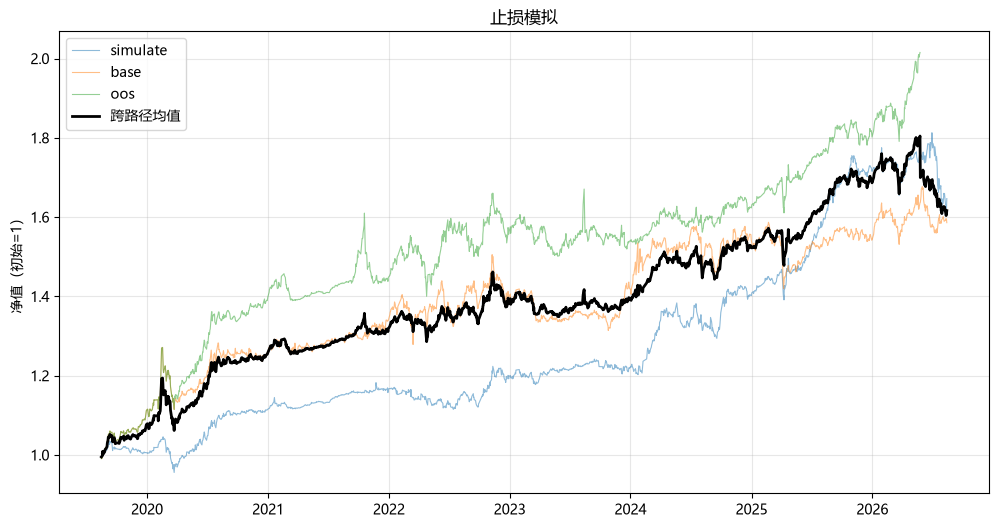

In [36]:
sl_mpts = Population([res['mpt'], base['mpt'], oos_mpt])
plot_paths_curve(sl_mpts, title='止损模拟', labels=['simulate','base', 'oos'])

In [38]:
# 可选传基准供画图：simulate_sl(..., bench=bench_ret)，结果在 res["bench"]
cmp_tbl = summarize_sl(res, base)
cmp_tbl

,年化收益,年化夏普,最大回撤,期末净值,epoch数,止损次数,到期换仓,新搜索(fresh),复用(fold),跳过重搜,交易起点,交易终点
SL模拟,0.0772,0.9887,0.1086,1.6465,15,1,13,15,0,0,2019-08-16,2026-08-14
无止损基线,0.0734,0.7439,0.127,1.5858,15,3,11,13,2,0,2019-08-16,2026-08-14


In [67]:
print(res["daily"].loc[res["daily"]["trigger"] != ""])  # 仅触发日

                          date  epoch  day_in_epoch       ret  net_global  \
1556 2026-07-28 00:00:00+08:00      6            45 -0.041411     1.63668   

      net_epoch  cum_epoch  dd_epoch  hit_epoch_dd   trigger  
1556   0.993172  -0.006828 -0.102681          True  epoch_dd  


In [ ]:
# 2) 落盘（与既有 log_result 体系一致）
#log_result(cmp_tbl,         section="SL模拟 vs 无止损基线")
#log_result(res["epochs"],   section="SL 模拟 epoch 明细")
#log_result(res["triggers"], section="SL 触发明细")

In [39]:
for pf in res['legs']:
    print(pf.assets)

['160128.SZ' '160140.SZ' '511260.SH']
['160921.SZ' '161014.SZ' '161115.SZ' '161727.SZ' '167002.SZ' '501053.SH'
 '501300.SH' '511220.SH' '511880.SH' '513500.SH']
['160128.SZ' '160220.SZ' '160515.SZ' '160613.SZ' '162712.SZ' '166008.SZ'
 '511220.SH']
['160128.SZ' '160618.SZ' '161010.SZ']
['160128.SZ' '161224.SZ' '511880.SH']
['160910.SZ' '161126.SZ' '511260.SH' '518600.SH']
['160910.SZ' '161029.SZ' '161126.SZ' '162719.SZ' '511260.SH' '518600.SH']
['161015.SZ' '511260.SH' '518600.SH']
['161029.SZ' '162719.SZ' '167002.SZ' '511260.SH' '518600.SH']
['160719.SZ' '161713.SZ' '501018.SH' '501076.SH' '511060.SH']
['160140.SZ' '160416.SZ' '160910.SZ' '161115.SZ' '511260.SH' '518600.SH']
['159611.SZ' '159816.SZ' '161115.SZ' '167002.SZ' '501073.SH' '511010.SH'
 '512730.SH' '515220.SH' '516770.SH']
['161029.SZ' '161119.SZ' '161128.SZ' '161216.SZ' '161614.SZ' '518860.SH']
['161010.SZ' '161115.SZ' '163116.SZ' '168401.SZ' '501073.SH' '501225.SH'
 '508011.SH' '508017.SH' '508018.SH' '508026.SH' '508031.S

### Fresh CPCV

In [11]:
cfg = load_sl_config(); cfg['space'] = search_space; cfg['search_kwargs'] = search_params
X_cut = X.tail(search_params['train_size'] + 1)      # 搜索窗口 + 1 天建仓日
final = simulate_sl(X_cut, cfg=cfg, conditions=[])   # 不传 folds → 全程 fresh；conditions=[] 纯搜索
# 参数记录: final['searches']  |  建仓头寸: final['legs'][0].weights / .assets

决策日 2026-09-17: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0: 2026-09-18 -> 2026-09-18 (1d, end_of_data) | src=fresh | ASR=nan | 累计=0.98%


In [18]:
final['mpt'].assets

[array(['160225.SZ', '501046.SH', '511270.SH', '513000.SH', '516310.SH',
        '560780.SH'], dtype=object)]

In [12]:
# 单轮（实盘前最后一次搜索）场景：
rec   = next(iter(final["searches"].values()))
study = rec["study"]          # ← optuna Study 对象，trial 级全历史：trial.params / trial.value / trial.state

# 直接喂给体系里消费 study 的函数：
from cpcv_analysis import empirical_deflate, top_trials
d     = empirical_deflate(study)            # margin / max_p95 / n_trials_total 全套（从 study 现算，无重算搜索）
cands = top_trials(study.trials, k=10)      # Top-K 候选

(array([ 5.,  8.,  4., 10., 18., 11., 10.,  8.,  7., 10.]),
 array([-0.26902338, -0.14740903, -0.02579467,  0.09581968,  0.21743404,
         0.33904839,  0.46066274,  0.5822771 ,  0.70389145,  0.82550581,
         0.94712016]),
 <BarContainer object of 10 artists>)

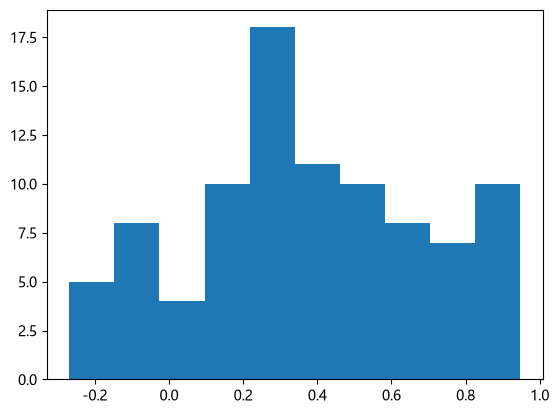

In [14]:
plt.hist(d['scores'])

In [19]:
1/6

0.16666666666666666